# Zomato Data Analysis -

In [6]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# creating dataframe from csv
df = pd.read_csv("Zomato data.csv")
df.sample(5)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
61,Goa 0 Km,Yes,Yes,3.6/5,163,800,Dining
111,Atithi Point Ande Ka Funda,No,No,3.1/5,29,150,Dining
43,Domino's Pizza,Yes,No,3.9/5,540,800,Dining
110,Hari Super Sandwich,No,No,3.2/5,0,200,Dining
48,Beijing Bites,Yes,No,3.7/5,679,850,Dining


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [9]:
# converting Data of 'rate' column by getting the first value and removing after slash value. 
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
df.sample(5)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
116,Wood Stove,No,No,3.4,0,150,Dining
17,Kirthi's Biryani,Yes,No,3.8,144,700,Cafes
121,New Mangalore Lunch Home,No,No,3.3,7,200,Dining
142,Gawdaru Mane Beriyani,No,No,3.3,0,300,Dining
131,Foodlieious Multi Cuisine,No,No,3.4,0,100,Dining


## Q1. What type of restaurant does the majority of people order from ?

# Type of Restaurant

df.sample(5)

Text(0.5, 0, 'Type of Restaurant')

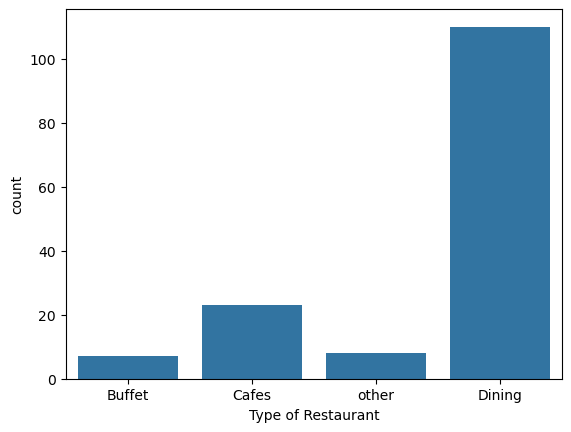

In [14]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of Restaurant")

+ ### Majority of restaurants are Dining type.

## Q2. How many votes has each type of restaurant recieved from customers ?

In [16]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


                 votes
listed_in(type)       
Buffet            3028
Cafes             6434
Dining           20363
other             9367


Text(0, 0.5, 'Votes')

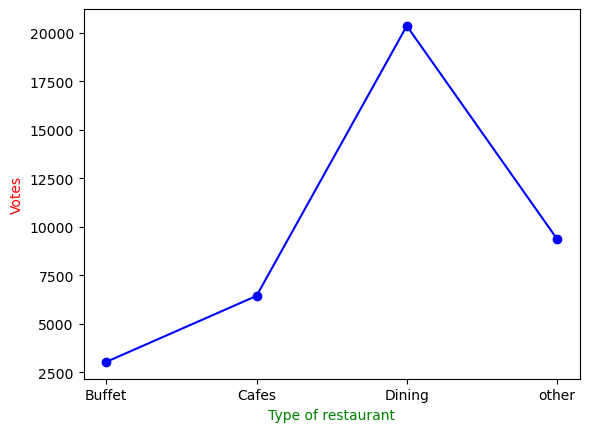

In [31]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
print(result)
plt.plot(result, c='blue', marker='o')
plt.xlabel('Type of restaurant', c='green', size=10)
plt.ylabel('Votes', c='red', size=10)

+ ### 'Dining' Restaurant type has highest votes - 20363,'other' - 9367, 'Cafes'- 6434 and 'Buffet'- 3028.

## Q3. What are the ratings that majority of restaurants have recieved ?

In [32]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


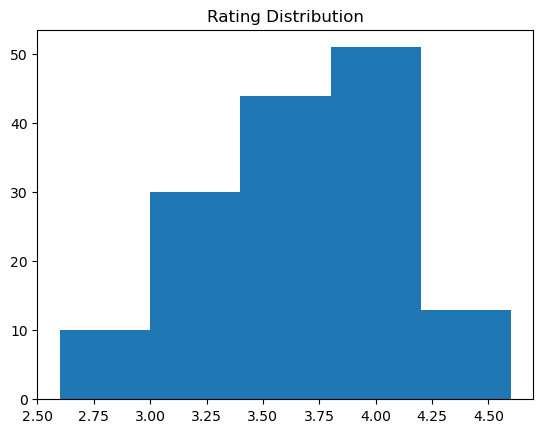

In [35]:
plt.hist(df['rate'],bins=5)
plt.title('Rating Distribution')
plt.show()

+ ### The Majority of restaurants have ratings in between 3.50 to 4.00

## Q4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

In [36]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [42]:
# Average order spending by couples.

In [46]:
avg_order_cost = df['approx_cost(for two people)'].mean()
avg_order_cost

418.2432432432432

+ ## The average order cost for couple is 418.2432432432432

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

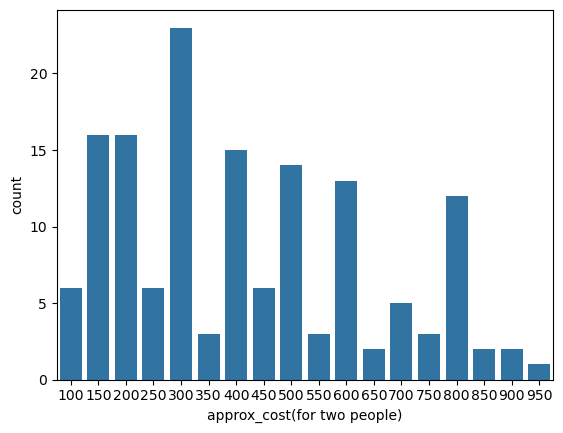

In [41]:
sns.countplot(x=df['approx_cost(for two people)'])

+ ### The majority of couples preffered the restaurants with the approx value of cost 300. 

## Q5.Which mode online or offline has received maximum rating ? 

In [48]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [49]:
#  by drawing box plot for rating and online order.

<Axes: xlabel='online_order', ylabel='rate'>

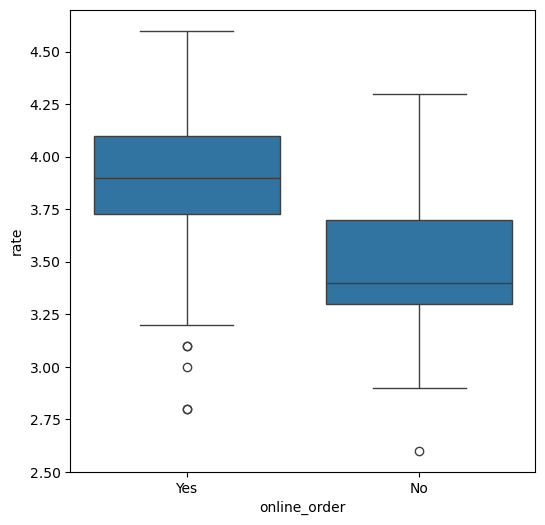

In [53]:
plot = plt.figure(figsize = (6, 6))
sns.boxplot(x='online_order', y='rate', data =df)

+ ### Offline order received lower rating in comparison to online order.

## Q5. Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

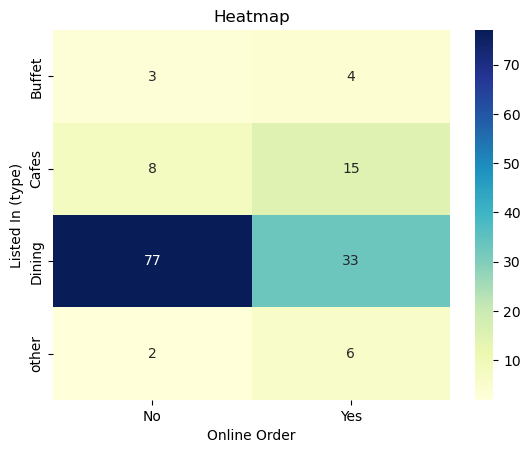

In [56]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (type)')
plt.show()

+ ### Dining restaurants primarily accept offline orders, whereas cafes primarily receive online orders. This suggests the clients prefernces orders in person at restaurants, but prefer online ordering at cafes.